Când auzim despre AI, ne gândim imediat la ChatGPT, roboți sau imagini generate pe calculator. Pentru a înțelege cum funcționează, trebuie să privim AI-ul ca pe o serie de domenii incluse unele în altele:

1. **Inteligența Artificială (AI):** Conceptul umbrelă. Orice sistem informatic capabil să imite inteligența umană. La extremitatea teoretică a acestui domeniu se află **AGI (Artificial General Intelligence)** – un sistem ipotetic viitor care ar avea capacitatea să înțeleagă și să învețe orice sarcină intelectuală la fel de bine ca un om.
2. **Machine Learning (ML):** Subdomeniul practic al AI-ului în care calculatorul învață din *date* în loc să fie programat cu reguli stricte. Aici se află algoritmul pe care îl vom programa astăzi.
3. **Deep Learning (Rețele Neuronale):** O ramură a ML-ului inspirată de arhitectura creierului uman. Folosește straturi de "neuroni artificiali" pentru a rezolva probleme foarte complexe (ex: recunoaștere facială, traducere simultană).
4. **Generative AI (AI Generativ):** Vârful de lance din prezent (ex: ChatGPT, Gemini, Midjourney). Sunt modele bazate pe rețele neuronale masive care nu doar analizează informații, ci sunt capabile să **genereze** conținut complet nou și original.

### Programarea Clasică vs. Machine Learning
Astăzi vom construi fundația voastră în acest univers, începând cu nivelul de Machine Learning.

În programarea clasică scrii **regulile** (`if`, `for`), introduci **datele**, iar calculatorul îți dă **răspunsurile**.
În Machine Learning, inversăm procesul. Îi dăm calculatorului **datele** și **răspunsurile corecte** (istoricul), iar el trebuie să calculeze și să descopere singur **regulile** (tiparele). Aceste reguli deduse matematic formează ceea ce numim un **Model de ML**.

## 2. Teoria din spatele Regresiei Liniare

### Intuiția
Imaginați-vă un grafic cu puncte (scatter plot) care arată venitul mediu al unei familii pe axa X și valoarea casei pe axa Y. Regresia Liniară trage **cea mai bună linie dreaptă** printre aceste puncte. 

Odată ce avem această linie, dacă vine o familie nouă cu un venit pe care nu l-am mai văzut, ne uităm pe linie și putem **prezice** cât va costa casa lor.

### Matematica (Simplificată)
Ecuația unei drepte învățate la matematică este:
$$y = mx + n$$

În Machine Learning, notația standard folosește "ponderi" (weights - $w$) și un "termen liber" (bias - $b$):
$$\hat{y} = w \cdot x + b$$

* $x$ = **Feature** (Funcționalitatea / Datele de intrare, ex: Venitul familiei).
* $\hat{y}$ = **Predicția** modelului (Valoarea estimată a casei).
* $w$ = **Ponderea** (Cât de mult influențează venitul prețul casei - panta dreptei).
* $b$ = **Bias-ul** (De unde începe linia pe axa Y, independent de venit).

Modelul nostru de ML va porni cu valori la întâmplare pentru $w$ și $b$. 

### Cum învață modelul? (Funcția de Pierdere)
Cum știe calculatorul că a găsit "cea mai bună linie"? Calculează **Eroarea Pătratică Medie (MSE - Mean Squared Error)**. 
Pentru fiecare punct real din datele noastre ($y$), măsoară distanța până la linia prezisă ($\hat{y}$), o ridică la pătrat (pentru a elimina valorile negative și a penaliza erorile mari) și face media.

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Scopul algoritmului în timpul "antrenării" (training) este să modifice $w$ și $b$ astfel încât această eroare ($MSE$) să devină cât mai aproape de zero.

## 3. Pașii creării unui Model în Scikit-Learn

Indiferent de algoritm (regresie liniară, rețele neuronale simple, arbori de decizie), în `scikit-learn` vom urma aproape mereu acești 4 pași:

1. **Pregătirea datelor:** Separăm datele în `X` (ce știm / cauzele) și `y` (ce vrem să prezicem / efectul).
2. **Train/Test Split:** Împărțim datele în două bucăți. Un set de "Antrenare" (pe care modelul învață) și un set de "Testare" (pe care îl ținem ascuns pentru a-i da un examen la final). Niciodată nu testăm modelul pe datele pe care le-a văzut deja, pentru că ar putea pur și simplu să le memoreze.
3. **Inițializarea și Antrenarea:** Creăm modelul și apelăm funcția `.fit(X_train, y_train)`.
4. **Predicția și Evaluarea:** Folosim `.predict(X_test)` și comparăm rezultatele cu realitatea.

In [1]:
# 4. Exemplu Practic: Regresia Liniară pe datele "housing.csv"

# Importăm bibliotecile necesare
import pandas as pd
import matplotlib.pyplot as plt

# Din scikit-learn importăm algoritmul și uneltele de evaluare
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Încărcăm datele
df = pd.read_csv("housing.csv")

# Ne asigurăm că nu avem valori lipsă (curățare rudimentară)
df = df.dropna()

# Definim X (Feature-ul - Venitul) și y (Target-ul - Valoarea casei)
# ATENȚIE: scikit-learn cere ca X să fie un tabel 2D (de aceea folosim [[ ]]), iar y un array 1D
X = df[["median_income"]] 
y = df["median_house_value"]

# 2. Împărțim datele: 80% pentru antrenare (învățare), 20% pentru testare (examen)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Date de antrenare: {len(X_train)} rânduri")
print(f"Date de testare: {len(X_test)} rânduri")

Date de antrenare: 16346 rânduri
Date de testare: 4087 rânduri


In [2]:
# 3. Creăm și Antrenăm modelul
model = LinearRegression()

# Aici se întâmplă matematica din spate (găsirea lui w și b pentru a minimiza eroarea)
model.fit(X_train, y_train)

# Putem să ne uităm "sub capotă" să vedem ce a învățat
w = model.coef_[0]
b = model.intercept_

print(f"Ecuația dreptei găsite: Preț = {w:.2f} * Venit + {b:.2f}")

# 4. Facem predicții pe datele pe care modelul NU le-a mai văzut (Examenul)
predictii = model.predict(X_test)

# Măsurăm cât a greșit în medie
eroare_mse = mean_squared_error(y_test, predictii)
# Extragem radicalul pentru a avea eroarea în dolari (RMSE)
eroare_medie_dolari = eroare_mse ** 0.5 

print(f"În medie, modelul nostru greșește cu aproximativ {eroare_medie_dolari:.2f} dolari.")

Ecuația dreptei găsite: Preț = 41751.96 * Venit + 45035.23
În medie, modelul nostru greșește cu aproximativ 84976.53 dolari.


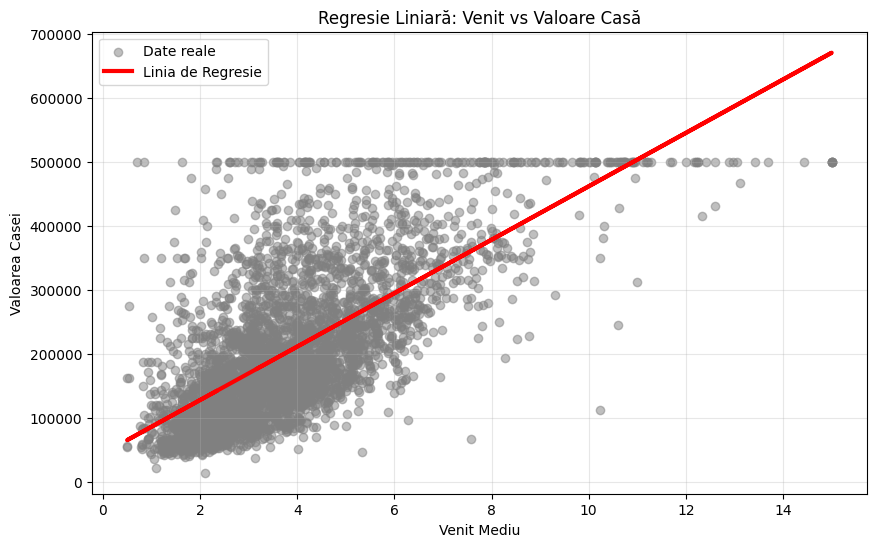


Pentru o zonă cu venitul 6.5, modelul prezice o valoare a casei de: 316422.95 dolari.


In [3]:
# 5. Vizualizarea rezultatului
plt.figure(figsize=(10, 6))

# Desenăm punctele REALE din setul de testare (cu gri)
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label='Date reale')

# Desenăm LINIA (predicțiile modelului nostru - cu roșu)
plt.plot(X_test, predictii, color='red', linewidth=3, label='Linia de Regresie')

plt.title('Regresie Liniară: Venit vs Valoare Casă')
plt.xlabel('Venit Mediu')
plt.ylabel('Valoarea Casei')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Test cu un venit complet nou introdus de noi:
venit_nou = pd.DataFrame({"median_income": [6.5]}) # Venit de 6.5
pret_estimat = model.predict(venit_nou)
print(f"\nPentru o zonă cu venitul 6.5, modelul prezice o valoare a casei de: {pret_estimat[0]:.2f} dolari.")